In [1]:
import pandas as pd
import numpy as np
import itertools
from sklearn.preprocessing import MinMaxScaler
from datetime import timedelta


In [2]:
data_path = r"/Users/ysl/Documents/DefiTradingBot/PairsTrading/binance_features_all_1d_interval.feather"
df = pd.read_feather(data_path)
columns = ["DateTime", "StockID", "Open", "High", "Low", "Close", "Vol", "Ret"]

full_df = df.sort_values(["DateTime", "StockID"]).reset_index(drop=True)
full_df = full_df.rename(columns={"StockID": "AssetName"})
unique_assets = full_df["AssetName"].unique()
# filter on USDT 
usdt_df = full_df.loc[full_df["AssetName"].str.contains("USDT")]


In [3]:
print(f"Unique Assets: {len(unique_assets)}")
print(f"Assets with USDT: {len(usdt_df["AssetName"].unique())}")

Unique Assets: 1454
Assets with USDT: 412


In [4]:
def zscore(series, window=20):
    return (series - series.rolling(window).mean()) / series.rolling(window).std()

def sharpe_ratio(returns, risk_free_rate=0.0422):
    # Assumes daily returns, annualizes by sqrt(252)
    excess_ret = returns - risk_free_rate/252
    return np.mean(excess_ret) / np.std(excess_ret) * np.sqrt(252) if np.std(excess_ret) > 0 else np.nan

In [5]:
# HYPER parameters
TRAIN_DATA = 0.6
VALIDATION_DATA = 0.3
TEST_DATA = 0.1
# 
train_cutoff_date = usdt_df["DateTime"].iloc[int(len(usdt_df) * TRAIN_DATA)]
validation_cutoff_date = usdt_df["DateTime"].iloc[int(len(usdt_df) * (TRAIN_DATA + VALIDATION_DATA))]
train_df_idx = usdt_df["DateTime"] < train_cutoff_date
validation_df_idx = (usdt_df["DateTime"] >= train_cutoff_date) & (usdt_df["DateTime"] < validation_cutoff_date)
test_df_idx = usdt_df["DateTime"] >= validation_cutoff_date
train_df = usdt_df.loc[train_df_idx]
validation_df = usdt_df.loc[validation_df_idx]
test_df = usdt_df.loc[test_df_idx]

In [6]:
print(usdt_df["DateTime"].min(), train_cutoff_date, validation_cutoff_date)

2017-08-18 00:00:00+00:00 2023-12-25 00:00:00+00:00 2025-03-07 00:00:00+00:00


In [7]:
# 1. scale the data
scaler = MinMaxScaler()
scaler.fit(train_df[["Close"]])
train_df.loc[:, "Close"] = scaler.transform(train_df[["Close"]])
validation_df.loc[:, "Close"] = scaler.transform(validation_df[["Close"]])
test_df.loc[:, "Close"] = scaler.transform(test_df[["Close"]])

In [8]:
pivot_df = train_df.pivot(index="DateTime", columns="AssetName", values="Close")
assets = pivot_df.columns.tolist()
pairs = list(itertools.combinations(assets, 2))

## Testing purposes
1. Identify the pairs whose returns are close enough using euclidean distance <br>
1.a Using non-parametric SSD based <br>
1.a.1 select top 20 pairs with minimum SSD <br>
1.a.2 select pairs with frequent zero crossing **TODO** <br>
1.a.3 select pairs with high std **TODO** <br>
1.b Using Cointegration test to identify **TODO** <br>



In [9]:
distance_dict = {}
std_of_distance_dict = {}
availability_status_dict = {}

In [10]:
results = []
for a1, a2 in pairs:
    pair_df = pivot_df[[a1, a2]].dropna() # drop if pairs are empty
    if len(pair_df) < 30 * 2: # if less than 2 months of data, skip
        continue
    min_time = pair_df.index.min()
    max_time = pair_df.index.max()
    availability_status_dict[f"{a1}_{a2}"] = {"min_time": min_time, "max_time": max_time, "data_point": len(pair_df)}
    spread = pair_df[a1] - pair_df[a2] # spread = a1 - a2 --> long the spread means long a1, short a2, short the spread means short a1, long a2
    ssd = np.sum(spread ** 2)
    distance_dict[f"{a1}_{a2}"] = ssd
    std_of_distance_dict[f"{a1}_{a2}"] = np.std(spread)
print(f"processed total of {len(availability_status_dict)} pairs")

processed total of 39060 pairs


In [11]:
# filter for top 20 pairs with lowest SSD
sorted_distance = sorted(distance_dict.items(), key=lambda x: x[1])
top_n = 20
top_pairs = sorted_distance[:top_n]

In [12]:
top_pairs

[('BTTCUSDT_PEPEUSDT', np.float64(1.8837666890294555e-20)),
 ('FLOKIUSDT_XECUSDT', np.float64(1.3455194522133497e-18)),
 ('PEPEUSDT_SHIBUSDT', np.float64(1.685197170083384e-18)),
 ('FLOKIUSDT_SHIBUSDT', np.float64(1.2507059655696923e-17)),
 ('BTTCUSDT_SHIBUSDT', np.float64(1.5306173341430674e-17)),
 ('FLOKIUSDT_PEPEUSDT', np.float64(2.2861218763696877e-17)),
 ('PEPEUSDT_XECUSDT', np.float64(2.3818872995706478e-17)),
 ('BTTCUSDT_FLOKIUSDT', np.float64(2.4059158129338797e-17)),
 ('FLOKIUSDT_WINUSDT', np.float64(6.551406222899018e-17)),
 ('FLOKIUSDT_LUNCUSDT', np.float64(1.5656076807723944e-16)),
 ('PEPEUSDT_WINUSDT', np.float64(1.6232772253715573e-16)),
 ('BTTCUSDT_XECUSDT', np.float64(1.9497200078939736e-16)),
 ('LUNCUSDT_PEPEUSDT', np.float64(2.899592835882203e-16)),
 ('LUNCUSDT_WINUSDT', np.float64(4.219325248236014e-16)),
 ('SHIBUSDT_XECUSDT', np.float64(5.814405582790432e-16)),
 ('LUNCUSDT_XECUSDT', np.float64(1.0428471818495377e-15)),
 ('LUNCUSDT_SHIBUSDT', np.float64(1.39449408947

In [13]:
# define the trading rules
# for each of the pair, if the spread > 2 std, short the spread
# if the spread < -2 std, long the spread
val_pivot = validation_df.pivot(index="DateTime", columns="AssetName", values="Close").sort_index()
position_report = {}
spread_report = {}
crossing_count = {pair: 0 for (pair, spread) in top_pairs}
validation_results = []
for pair_key, _ in top_pairs:
    if pair_key not in std_of_distance_dict:
        print(f"Pair Key of {pair_key} not in std_of_distance_dict, skipping...")
        continue
    a1, a2 = pair_key.split("_")
    if a1 not in val_pivot.columns or a2 not in val_pivot.columns:
        print(f"One of the assets in pair {pair_key} not in validation data, skipping...")
        continue

    pair_df = val_pivot[[a1, a2]].dropna()
    pair_df["spread"] = pair_df[a1] - pair_df[a2]
    spread_report[pair_key] = pair_df
    if len(pair_df) < 10:
        print("Not enough data points in validation for pair {pair_key}, skipping...")
        continue

    s1 = pair_df[a1]
    s2 = pair_df[a2]
    spread = pair_df["spread"]
    thr = 2 * std_of_distance_dict[pair_key]

    # scan and build discrete positions: 
    # +1 = long spread (long a1, short a2),
    # -1 = short spread (short a1, long a2), 
    # 0 = clear the position iff previous position exists and spread crosses zero
    pos = np.zeros(len(spread), dtype=int)
    cur_pos = 0
    for i in range(len(spread)):
        cur_spread = spread.iloc[i]
        if cur_pos == 0:
            if cur_spread > thr: # this is overvalued hence short the spread (short a1, long a2)
                cur_pos = -1  # short spread
            elif cur_spread < -thr: # this is undervalued hence long the spread (long a1, short a2)
                cur_pos = 1   # long spread
        else:
            # this is the case where previous position exists
            # determine if clear the position
            prev_spread = spread.iloc[i - 1] if i > 0 else cur_spread
            if cur_spread == 0 or prev_spread * cur_spread < 0:
                cur_pos = 0
                crossing_count[pair_key] += 1
        pos[i] = cur_pos

    pos_series = pd.Series(pos, index=spread.index)
    position_report[pair_key] = pos_series
    spread_ret = (s1.pct_change() - s2.pct_change()).fillna(0)
    strat_ret = pos_series.shift(1).fillna(0) * spread_ret  # apply yesterday's position to today's return

    cum_ret = (1 + strat_ret).cumprod() - 1
    final_cum = cum_ret.iloc[-1] if len(cum_ret) > 0 else 0
    sharpe = sharpe_ratio(strat_ret)

    validation_results.append({
        "pair": pair_key,
        "cum_return": final_cum,
        "sharpe": sharpe,
        "returns": strat_ret
    })

# show top validation results
validation = sorted(validation_results, key=lambda x: x["cum_return"], reverse=True)
for r in validation:
    print(f"Pair: {r['pair']}, Cumulative Return: {r['cum_return']:.2%}, Sharpe: {r['sharpe']:.2f}, Num of Cross: {crossing_count[r['pair']]}")
# exit when spread returns to mean


Pair: LUNCUSDT_PEPEUSDT, Cumulative Return: 1173.61%, Sharpe: 1.69, Num of Cross: 0
Pair: PEPEUSDT_XECUSDT, Cumulative Return: 653.35%, Sharpe: 1.47, Num of Cross: 0
Pair: PEPEUSDT_WINUSDT, Cumulative Return: 397.46%, Sharpe: 1.36, Num of Cross: 0
Pair: PEPEUSDT_SHIBUSDT, Cumulative Return: 327.35%, Sharpe: 1.23, Num of Cross: 0
Pair: FLOKIUSDT_LUNCUSDT, Cumulative Return: 168.85%, Sharpe: 0.98, Num of Cross: 1
Pair: LUNCUSDT_SHIBUSDT, Cumulative Return: 105.50%, Sharpe: 0.83, Num of Cross: 0
Pair: FLOKIUSDT_PEPEUSDT, Cumulative Return: 90.67%, Sharpe: 0.83, Num of Cross: 0
Pair: LUNCUSDT_XECUSDT, Cumulative Return: 5.50%, Sharpe: 0.30, Num of Cross: 0
Pair: FLOKIUSDT_WINUSDT, Cumulative Return: 4.56%, Sharpe: 0.56, Num of Cross: 1
Pair: LUNCUSDT_WINUSDT, Cumulative Return: 0.00%, Sharpe: -2802165968455726.00, Num of Cross: 0
Pair: SHIBUSDT_XECUSDT, Cumulative Return: 0.00%, Sharpe: -2802165968455726.00, Num of Cross: 0
Pair: WINUSDT_XECUSDT, Cumulative Return: 0.00%, Sharpe: -28021659

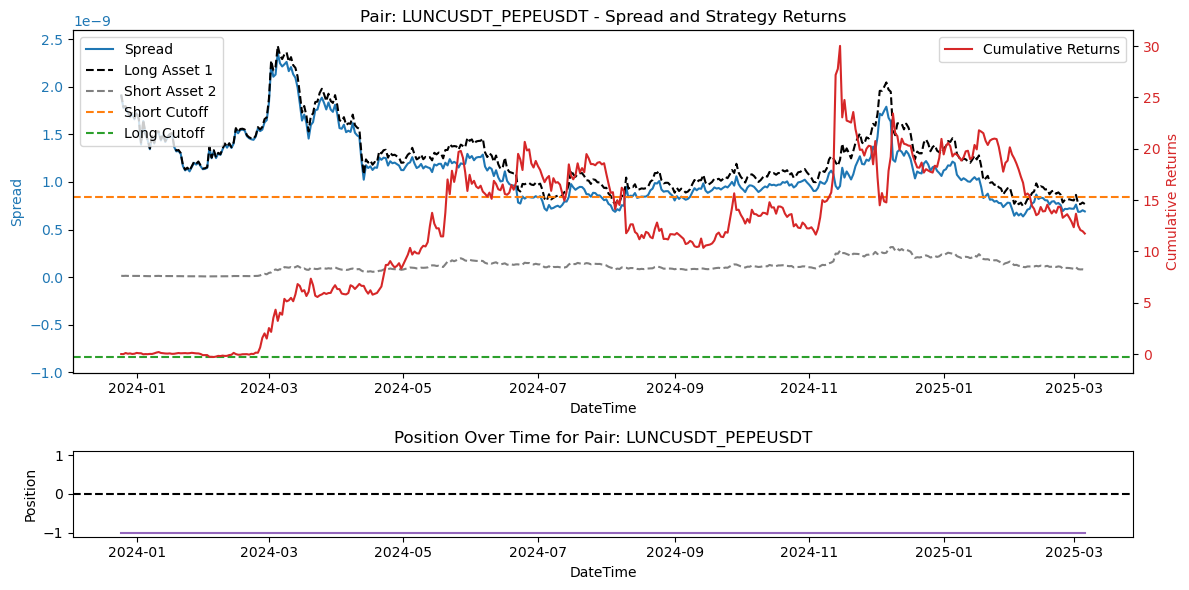

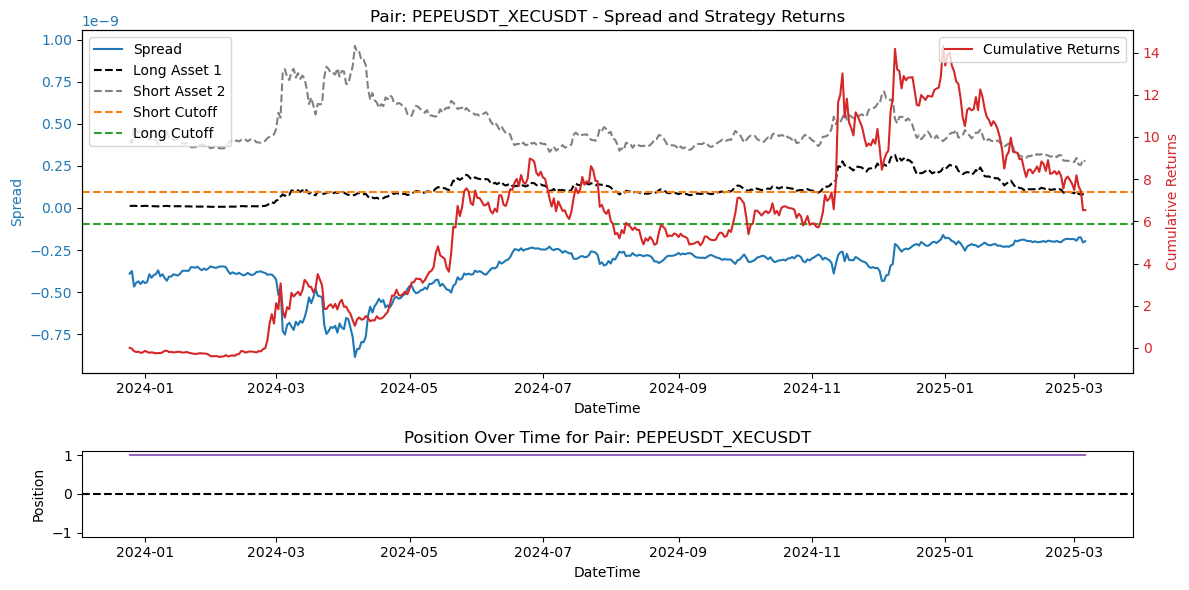

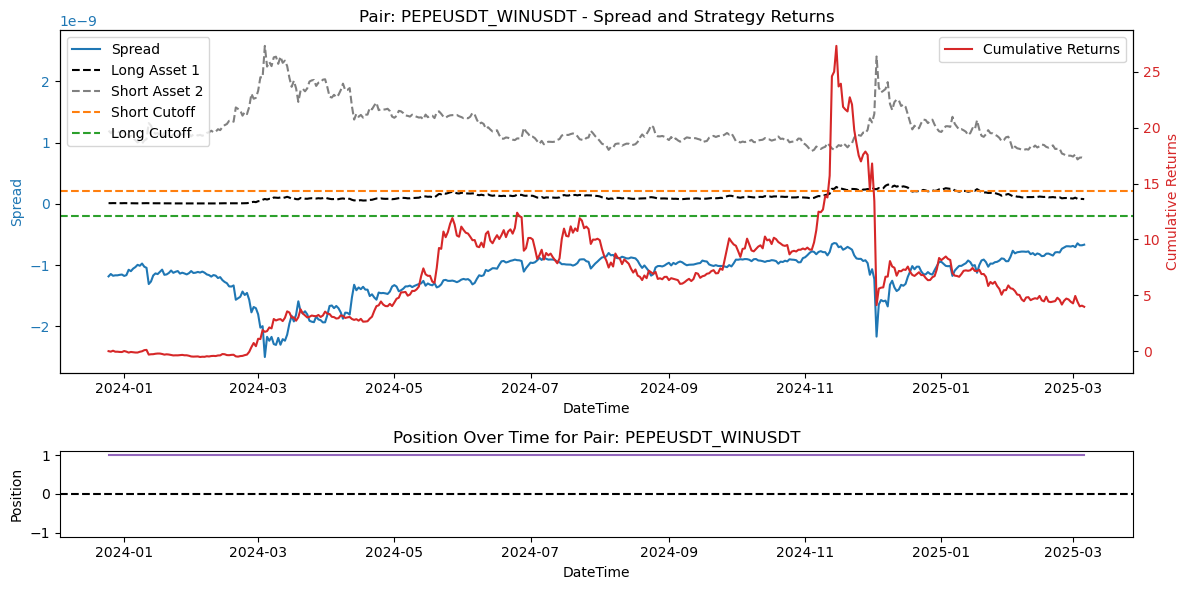

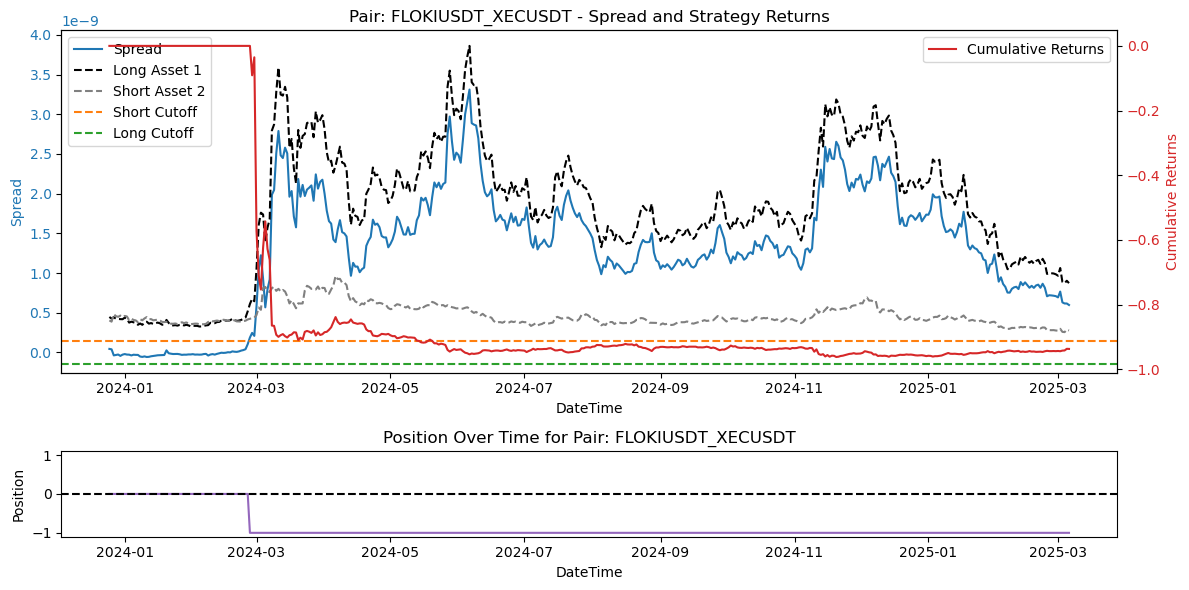

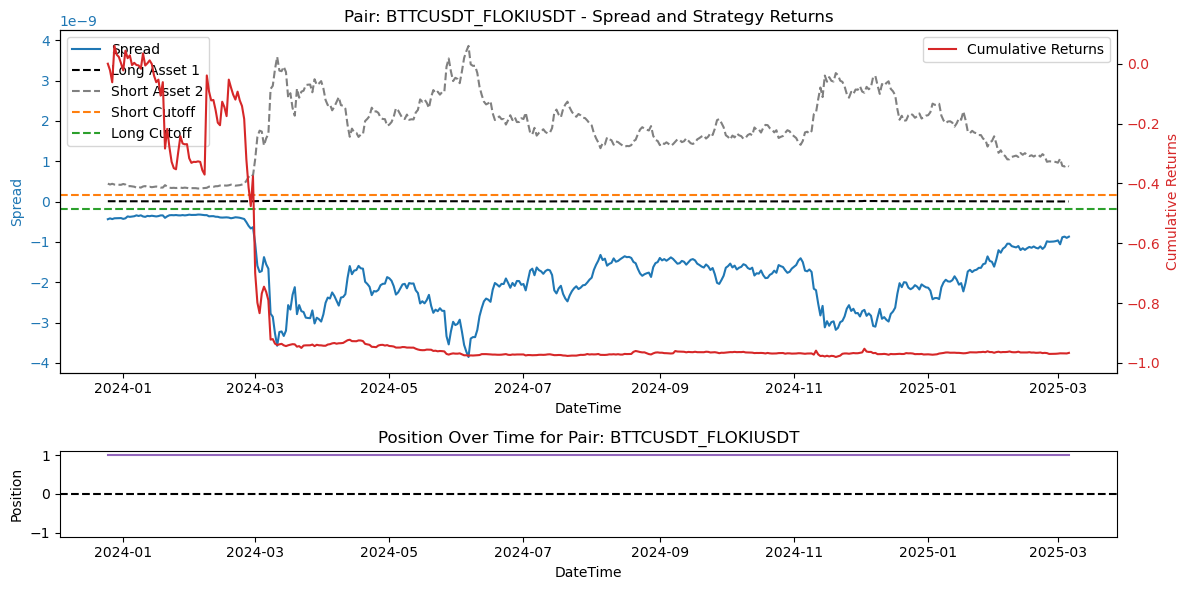

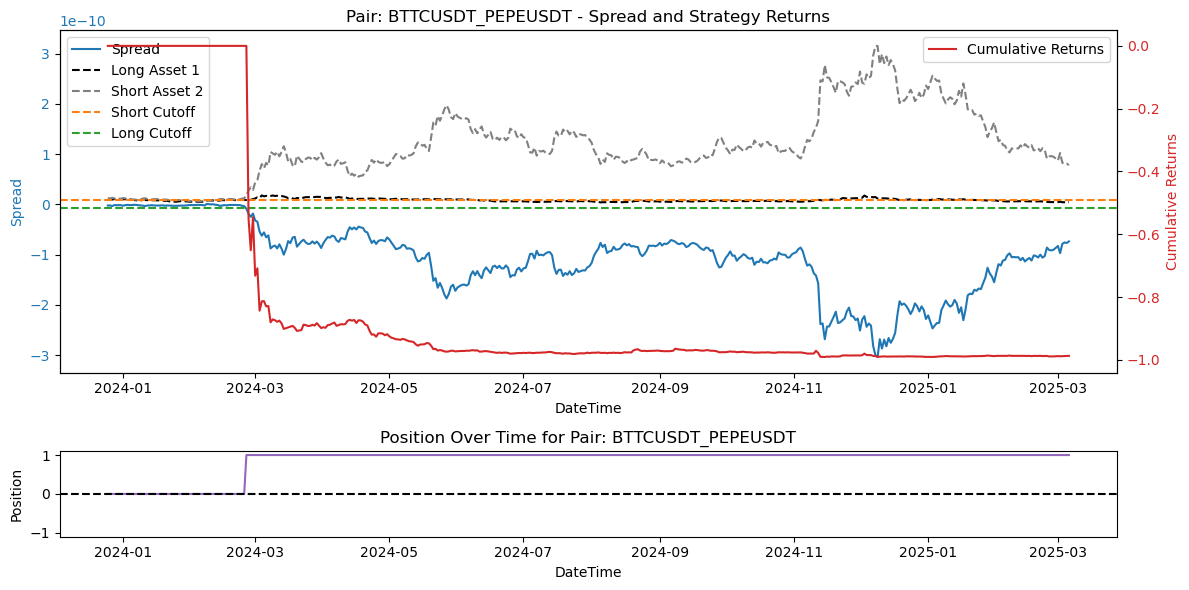

In [14]:
# plot return of top pairs with spread for top5 pairs and worst 5 pairs
top_n_plot = 3
top_validation = validation[:top_n_plot]
worst_validation = validation[-top_n_plot:]
import matplotlib.pyplot as plt
for r in top_validation + worst_validation:
    pair_key = r["pair"]
    spread_df = spread_report[pair_key]
    position_df = position_report[pair_key]
    
    returns = r["returns"]
    
    fig, (ax1, pos_lot) = plt.subplots(figsize=(12, 6), nrows=2, ncols=1, height_ratios=[8,2])
    
    ax1.set_title(f"Pair: {pair_key} - Spread and Strategy Returns")
    ax1.set_xlabel("DateTime")
    ax1.set_ylabel("Spread", color='tab:blue')
    asset1_name, asset2_name = pair_key.split("_")
    ax1.plot(spread_df.index, spread_df["spread"], label="Spread", color='tab:blue')
    ax1.plot(spread_df.index, spread_df[asset1_name], color='black', linestyle='--', label='Long Asset 1')
    ax1.plot(spread_df.index, spread_df[asset2_name], color='gray', linestyle='--', label='Short Asset 2')
    
    ax1.axhline(2 * std_of_distance_dict[pair_key], color='tab:orange', linestyle='--', label="Short Cutoff")
    ax1.axhline(-2 * std_of_distance_dict[pair_key], color='tab:green', linestyle='--', label="Long Cutoff")
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.set_ylabel("Cumulative Returns", color='tab:red')
    cum_returns = (1 + returns).cumprod() - 1
    ax2.plot(cum_returns.index, cum_returns, label="Cumulative Returns", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')
    
    pos_lot.set_title(f"Position Over Time for Pair: {pair_key}")
    pos_lot.set_xlabel("DateTime")
    pos_lot.set_ylabel("Position")
    pos_lot.plot(position_df.index, position_df, color='tab:purple')
    pos_lot.axhline(0, color='black', linestyle='--')
    pos_lot.set_ylim(-1.1, 1.1)
    
    fig.tight_layout()
    plt.show()


## Uses moving window to select latest top performing pairs and run pairs trading

In [15]:
from datetime import timedelta

window_months = 4 # 3 months of pair selection and 1 month of validation
window_days = window_months * 30  # Approximate days in 3 months
step_days = 30  # Move window by 1 month each time

train_df = train_df.sort_values("DateTime")
start_date = train_df["DateTime"].min()
end_date = train_df["DateTime"].max()
N_PAIRS = 10

results = []

current_start = start_date
while current_start + timedelta(days=window_days) <= end_date:
    current_end = current_start + timedelta(days=window_days)
    current_train_end = current_end - timedelta(days=step_days)  # last month for validation
    window_df = train_df[(train_df["DateTime"] >= current_start) & (train_df["DateTime"] < current_end)]
    pivot_window = window_df.pivot(index="DateTime", columns="AssetName", values="Close")
    pivot_window_selection_df = pivot_window.loc[pivot_window.index <= current_train_end]
    pivot_window_validation_df = pivot_window.loc[(pivot_window.index > current_train_end) & (pivot_window.index < current_end)]
    assets = pivot_window_selection_df.columns.tolist()
    pairs = list(itertools.combinations(assets, 2))
    
    # Measure Euclidean distance for each pair in this window
    distance_dict = {}
    for a1, a2 in pairs:
        pair_df = pivot_window_selection_df[[a1, a2]].dropna()
        if len(pair_df) < 30:  # skip if not enough data
            continue
        spread = pair_df[a1] - pair_df[a2]
        ssd = np.sum(spread ** 2)
        distance_dict[f"{a1}_{a2}"] = ssd
    
    # Select top N pairs with shortest distance
    sorted_distance = sorted(distance_dict.items(), key=lambda x: x[1])
    top_pairs = sorted_distance[:N_PAIRS]
    
    for pair_key, _ in top_pairs:
        a1, a2 = pair_key.split("_")
        pair_df = pivot_window_validation_df[[a1, a2]].dropna()
        if len(pair_df) < 10:
            print(f"Pair of {a1, a2} does not have enough data in validation, skipping...")
            continue
        spread = pair_df[a1] - pair_df[a2]
        thr = 2 * distance_dict[f"{a1}_{a2}"]
        pos = np.zeros(len(spread), dtype=int)
        cur_pos = 0
        for i in range(len(spread)):
            cur_spread = spread.iloc[i] # a1 - a2
            if cur_pos == 0:
                if cur_spread > thr:
                    cur_pos = -1
                elif cur_spread < -thr:
                    cur_pos = 1
            else:
                prev_spread = spread.iloc[i - 1] if i > 0 else cur_spread
                if cur_spread == 0 or prev_spread * cur_spread < 0:
                    cur_pos = 0
            pos[i] = cur_pos
        pos_series = pd.Series(pos, index=spread.index)
        s1 = pair_df[a1]
        s2 = pair_df[a2]
        spread_ret = (s1.pct_change() - s2.pct_change()).fillna(0)
        strat_ret = pos_series.shift(1).fillna(0) * spread_ret
        cum_ret = (1 + strat_ret).cumprod() - 1
        sharpe = sharpe_ratio(strat_ret)
        results.append({
            "window_start": current_start,
            "window_validation_start": current_train_end,
            "window_validation_end": current_end,
            "pair": pair_key,
            "cum_return": cum_ret.iloc[-1] if len(cum_ret) > 0 else 0,
            "sharpe": sharpe
        })
    
    current_start += timedelta(days=step_days)

# Show results for each window
for r in results:
    print(f"Window: {r['window_start'].date()}-{r['window_validation_start'].date()}-{r['window_validation_end'].date()}, Pair: {r['pair']}, Cumulative Return: {r['cum_return']:.2%}, Sharpe: {r['sharpe']:.2f}")


Pair of ('TUSDUSDT', 'USDCUSDT') does not have enough data in validation, skipping...
Pair of ('TUSDUSDT', 'USDPUSDT') does not have enough data in validation, skipping...
Pair of ('USDCUSDT', 'USDPUSDT') does not have enough data in validation, skipping...
Pair of ('TUSDUSDT', 'USDCUSDT') does not have enough data in validation, skipping...
Pair of ('TUSDUSDT', 'USDPUSDT') does not have enough data in validation, skipping...
Pair of ('USDCUSDT', 'USDPUSDT') does not have enough data in validation, skipping...
Pair of ('TUSDUSDT', 'USDCUSDT') does not have enough data in validation, skipping...
Pair of ('USDCUSDT', 'USDPUSDT') does not have enough data in validation, skipping...
Pair of ('TUSDUSDT', 'USDPUSDT') does not have enough data in validation, skipping...
Window: 2017-08-18-2017-11-16-2017-12-16, Pair: BTCUSDT_ETHUSDT, Cumulative Return: 0.00%, Sharpe: -32691936298650124.00
Window: 2017-09-17-2017-12-16-2018-01-15, Pair: BNBUSDT_ETHUSDT, Cumulative Return: 64.21%, Sharpe: 2.72


# using cointegration approach - WIP

In [20]:
unique_assets = train_df["AssetName"].unique()
full_pairs = itertools.combinations(unique_assets, 2)
full_pairs = [f"{a}_{b}" for a, b in full_pairs]
print(f"Assets : {len(unique_assets) * (len(unique_assets)-1) // 2}")

Assets : 42778


In [19]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

results = []
window_months = 4
window_days = window_months * 30
step_days = 30

train_df = train_df.sort_values("DateTime")
start_date = train_df["DateTime"].min()
end_date = train_df["DateTime"].max()
N_PAIRS = 10

In [ ]:
current_start = start_date
current_end = current_start + timedelta(days=step_days * 3 + 1)
pivot_df = train_df.pivot(index="DateTime", columns="AssetName", values="Close")
pvalue_df = pd.DataFrame(index=pivot_df.index, columns=full_pairs)
coef_df = pd.DataFrame(index=pivot_df.index, columns=full_pairs)
position_df = pd.DataFrame(index=pivot_df.index, columns=full_pairs)
return_df = pd.DataFrame(index=pivot_df.index, columns=full_pairs)
std_df = pd.DataFrame(index=pivot_df.index, columns=full_pairs)
mean_df = pd.DataFrame(index=pivot_df.index, columns=full_pairs)

while current_end <= end_date: # 3M train & 1M validation
    current_train_end = current_end - timedelta(days=1)
    window_df = pivot_df.loc[(pivot_df.index >= current_start) & (pivot_df.index <= current_train_end)]
    window_val_df = pivot_df.loc[(pivot_df.index > current_train_end) & (pivot_df.index <= current_end)]
    assets = window_df.columns.tolist()
    pairs = list(itertools.combinations(assets, 2))
    
    # 1. run linear regression to get coefficient
    for a1, a2 in pairs:
        pair_df = window_df[[a1, a2]].dropna()
        if len(pair_df) < 30:
            continue
        y = pair_df[a1]
        X = sm.add_constant(pair_df[a2])
        model = sm.OLS(y, X).fit()
        hedge_ratio = model.params[a2]
        coef_df.loc[current_train_end, f"{a1}_{a2}"] = hedge_ratio
        
        # 2. compute spread ( s = a1 - hedge_ratio * a2 )
        spread = pair_df[a1] - hedge_ratio * pair_df[a2]
        std_df.loc[current_train_end, f"{a1}_{a2}"] = spread.std()
        mean_df.loc[current_train_end, f"{a1}_{a2}"] = spread.mean()
        
        # 3. perform cointegration test using the linear regression
        coint_t, p_value, _ = coint(pair_df[a1], pair_df[a2])
        pvalue_df.loc[current_train_end, f"{a1}_{a2}"] = p_value
        
        if p_value < 0.05: # reject H0 -> exists cointegration
            results.append({
                "window_start": current_start,
                "validation_start": current_train_end,
                "window_end": current_end,
                "pair": f"{a1}_{a2}",
                "hedge_ratio": hedge_ratio,
                "coint_t": coint_t,
                "p_value": p_value
            })
        
        # 4. test the model performance on validation set
        val_pair_df = window_val_df[[a1, a2]].dropna()
        if len(val_pair_df) < 10:
            continue
        val_spread = val_pair_df[a1] - hedge_ratio * val_pair_df[a2]
        val_spread_mean = val_spread.mean()
        val_spread_std = val_spread.std()
        thr = 2 * val_spread_std
        
    
    current_start += timedelta(days=step_days)

Pair BNBUSDT_ETHUSDT is cointegrated with p-value 0.0103
Pair ETHUSDT_NEOUSDT is cointegrated with p-value 0.0219
Pair BNBUSDT_BTCUSDT is cointegrated with p-value 0.0164
Pair ETHUSDT_NEOUSDT is cointegrated with p-value 0.0170
Pair ETHUSDT_LTCUSDT is cointegrated with p-value 0.0059
Pair BNBUSDT_LTCUSDT is cointegrated with p-value 0.0172
Pair ETHUSDT_NEOUSDT is cointegrated with p-value 0.0184
Pair NEOUSDT_QTUMUSDT is cointegrated with p-value 0.0213
Pair BTCUSDT_QTUMUSDT is cointegrated with p-value 0.0010
Pair LTCUSDT_QTUMUSDT is cointegrated with p-value 0.0407
Pair ADAUSDT_TUSDUSDT is cointegrated with p-value 0.0411
Pair BTCUSDT_ETHUSDT is cointegrated with p-value 0.0036
Pair BTCUSDT_NEOUSDT is cointegrated with p-value 0.0281
Pair BTCUSDT_TUSDUSDT is cointegrated with p-value 0.0005
Pair ICXUSDT_XRPUSDT is cointegrated with p-value 0.0000
Pair LTCUSDT_QTUMUSDT is cointegrated with p-value 0.0326
Pair QTUMUSDT_XRPUSDT is cointegrated with p-value 0.0098
Pair ADAUSDT_NEOUSDT is 

KeyboardInterrupt: 